<a href="https://colab.research.google.com/github/awitz23/Diabetes_prediction/blob/main/model_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Dependencies

In [ ]:
!pip install ucimlrepo
!pip install catboost
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from ucimlrepo import fetch_ucirepo

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, precision_score, recall_score

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.feature_selection import RFE
from catboost import CatBoostClassifier
import pandas as pd
import numpy as np

from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
import numpy as np

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from scipy.stats import sem
import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names")

In [ ]:
# --- Fetch dataset ---
cdc_diabetes_health_indicators = fetch_ucirepo(id=891)
X = cdc_diabetes_health_indicators.data.features
Y = cdc_diabetes_health_indicators.data.targets
y = Y.values.ravel()

#Preprocessing

In [ ]:
# --- Step 1: Define feature types ---
binary_features = [
    'HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack',
    'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare',
    'NoDocbcCost', 'DiffWalk', 'Sex'
]

ordinal_features = ['GenHlth', 'Age', 'Education', 'Income']
ratio_features = ['BMI', 'MentHlth', 'PhysHlth']

In [ ]:
# --- Step 2: Define transformers ---
scaler = StandardScaler()
ordinal_encoder = OrdinalEncoder()

# Preprocessing pipeline for models that need scaling
preprocessor = ColumnTransformer([
    ('ratio', scaler, ratio_features),
    ('ordinal', ordinal_encoder, ordinal_features)
], remainder='passthrough')  # binary features remain untouched


rus = RandomUnderSampler(random_state=42)
X_bal, y_bal = rus.fit_resample(X, Y)

sampler = SMOTE(random_state=42)
X_sampled, y_sampled = sampler.fit_resample(X, y)
X_train, X_test, y_train, y_test = train_test_split(X_sampled, y_sampled, test_size=0.2, stratify=y_sampled, random_state=42)


#Preprocessing feature selection

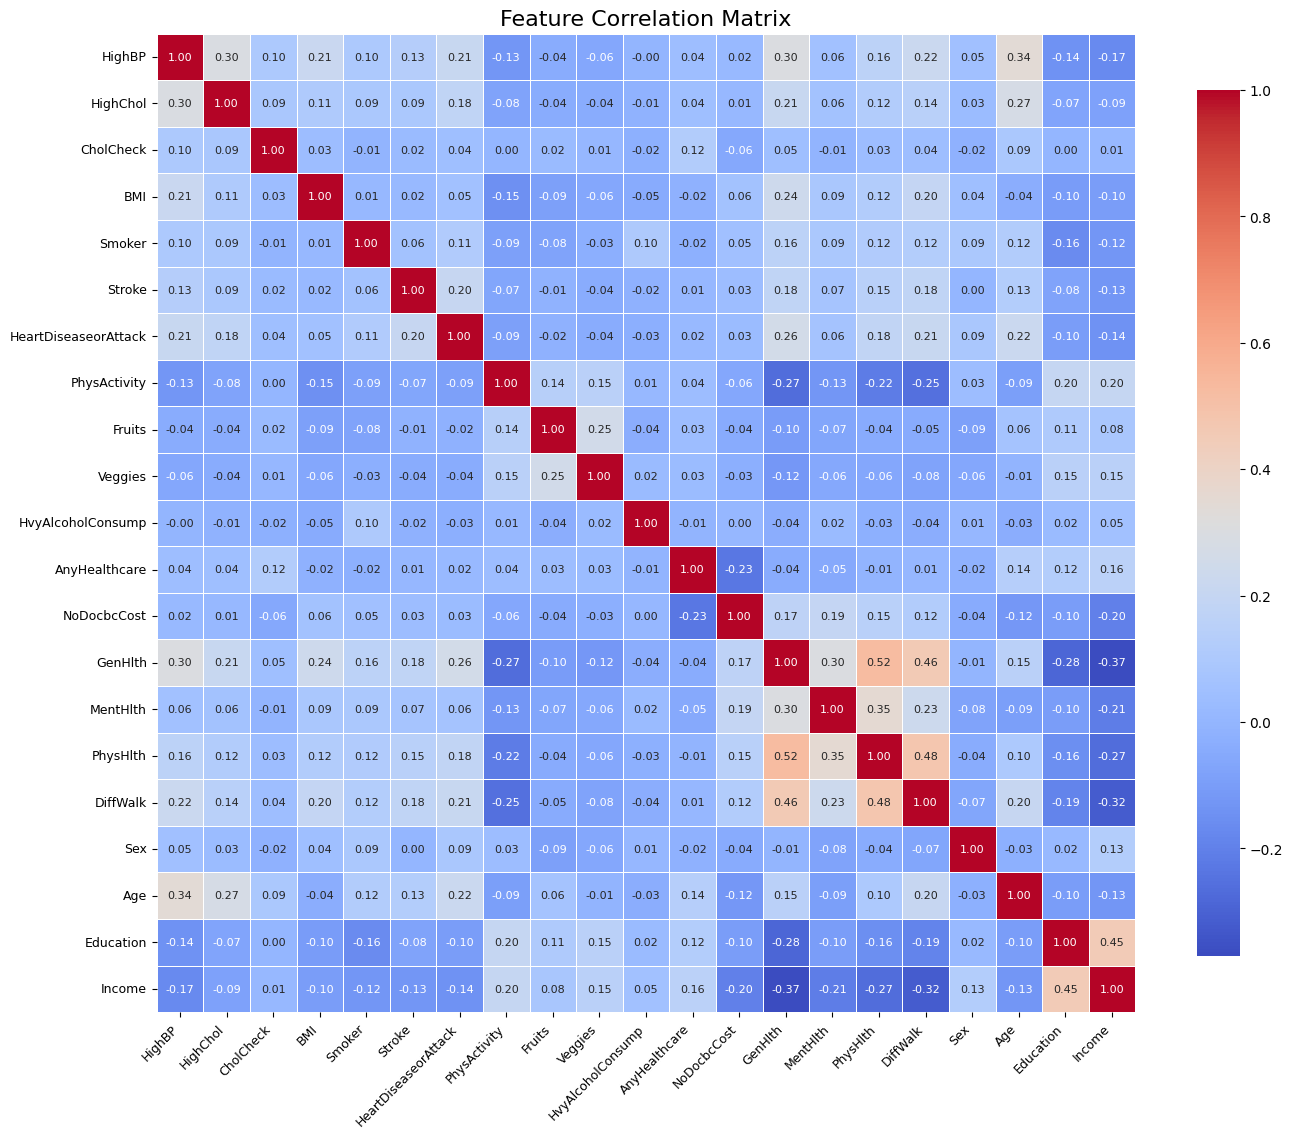

In [ ]:


plt.figure(figsize=(14, 12))  # Adjust the figure size as needed
corr = X.corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    annot_kws={"size": 8},
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.title('Feature Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.show()



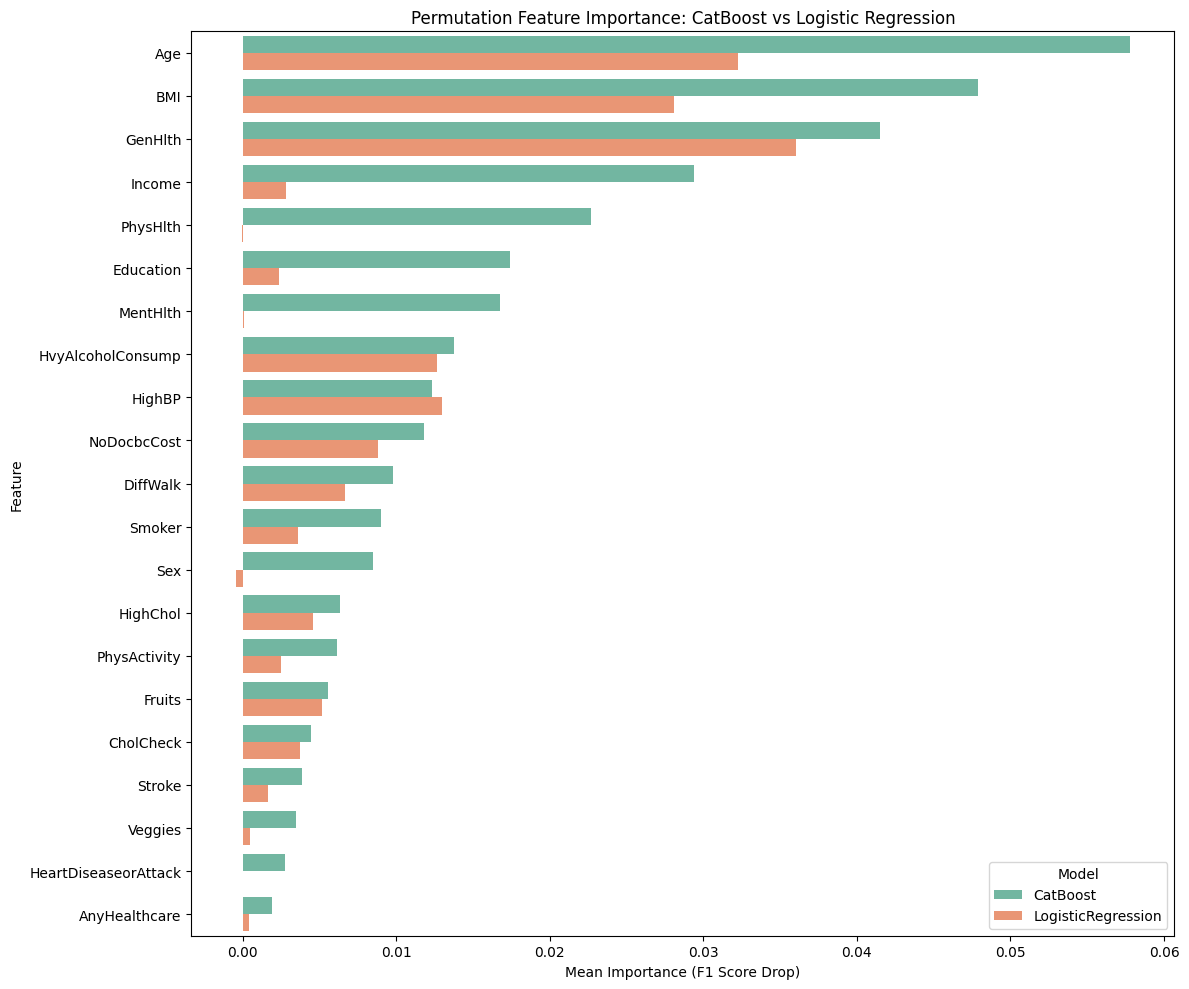

In [ ]:
#previous results have shown best performance for Catboost and Logistic Regression
# Ensure target is 1D
y_bal_1d = y_train #.values.ravel()

# ------------------ CATBOOST MODEL ------------------
catboost_model = CatBoostClassifier(verbose=0, random_state=42)
catboost_model.fit(X_train, y_bal_1d)

catboost_result = permutation_importance(
    catboost_model, X_train, y_bal_1d, scoring='f1', n_repeats=5, random_state=42
)

catboost_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance_mean': catboost_result.importances_mean,
    'importance_std': catboost_result.importances_std,
    'model': 'CatBoost'
})

# ------------------ LOGISTIC REGRESSION MODEL ------------------
logreg_model = LogisticRegression(max_iter=1000, random_state=42)
logreg_model.fit(X_train, y_bal_1d)

logreg_result = permutation_importance(
    logreg_model, X_train, y_bal_1d, scoring='f1', n_repeats=5, random_state=42
)

logreg_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance_mean': logreg_result.importances_mean,
    'importance_std': logreg_result.importances_std,
    'model': 'LogisticRegression'
})

# ------------------ COMBINE & PLOT ------------------
importance_df = pd.concat([catboost_importance, logreg_importance])
importance_df = importance_df.sort_values(by='importance_mean', ascending=False)

# Plot
plt.figure(figsize=(12, 10))
sns.barplot(
    data=importance_df,
    x='importance_mean',
    y='feature',
    hue='model',
    errorbar=('sd'),
    palette='Set2'
)
plt.title('Permutation Feature Importance: CatBoost vs Logistic Regression')
plt.xlabel('Mean Importance (F1 Score Drop)')
plt.ylabel('Feature')
plt.legend(title='Model')
plt.tight_layout()
plt.show()

In [ ]:
importance_df

,feature,importance_mean,importance_std,model
18,Age,0.057758,0.000263,CatBoost
3,BMI,0.047870,0.000500,CatBoost
13,GenHlth,0.041487,0.000552,CatBoost
13,GenHlth,0.036036,0.000516,LogisticRegression
18,Age,0.032278,0.000206,LogisticRegression
20,Income,0.029387,0.000218,CatBoost
3,BMI,0.028088,0.000505,LogisticRegression
15,PhysHlth,0.022699,0.000150,CatBoost
19,Education,0.017442,0.000150,CatBoost
14,MentHlth,0.016767,0.000185,CatBoost


Selected features by RFE with CatBoost:
Index(['HighBP', 'BMI', 'PhysActivity', 'HvyAlcoholConsump', 'GenHlth',
       'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income'],
      dtype='object')


/tmp/ipython-input-23-4137487964.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_ranking_df, x='ranking', y='feature', palette='viridis')


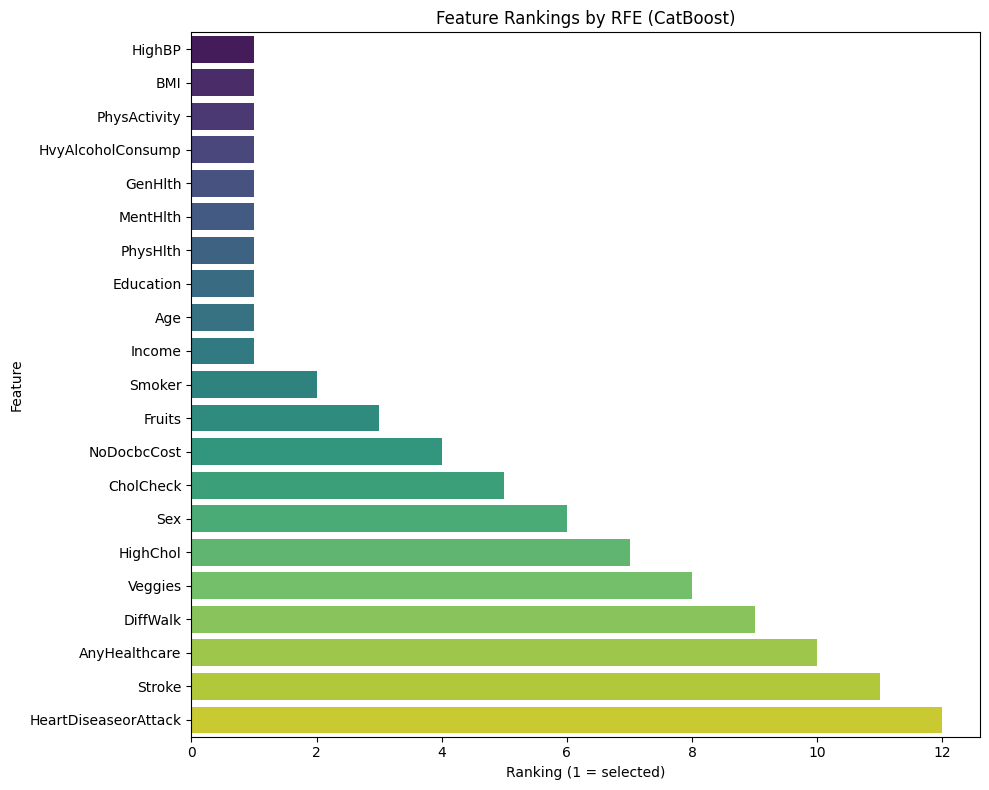

In [ ]:
y_bal_1d = y_train

# Wrapper class for CatBoost to have feature_importances_ property (read-only)
class CatBoostWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, **kwargs):
        self.model = CatBoostClassifier(**kwargs)

    def fit(self, X, y):
        self.model.fit(X, y, verbose=0)
        return self

    def predict(self, X):
        return self.model.predict(X)

    def predict_proba(self, X):
        return self.model.predict_proba(X)

    @property
    def feature_importances_(self):
        return self.model.get_feature_importance()

# Instantiate the CatBoost wrapper
catboost_wrapper = CatBoostWrapper(random_state=42)

# Create RFE with CatBoost as the estimator
rfe_catboost = RFE(estimator=catboost_wrapper, n_features_to_select=10, step=1)

# Fit RFE on data
rfe_catboost.fit(X_train, y_bal_1d)

# Extract selected features
selected_features = X_train.columns[rfe_catboost.support_]

print("Selected features by RFE with CatBoost:")
print(selected_features)

# Optional: visualize ranking of features
feature_ranking_df = pd.DataFrame({
    'feature': X_train.columns,
    'ranking': rfe_catboost.ranking_
}).sort_values('ranking')

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_ranking_df, x='ranking', y='feature', palette='viridis')
plt.title('Feature Rankings by RFE (CatBoost)')
plt.xlabel('Ranking (1 = selected)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

RESULT: In the end the best results were seen when all 21 features were included

# Algorithm Evaluation

In [ ]:
# --- Imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from ucimlrepo import fetch_ucirepo

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV, KFold
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, precision_score, recall_score

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from scipy.stats import sem
import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names")

In [ ]:
# --- Fetch dataset ---
cdc_diabetes_health_indicators = fetch_ucirepo(id=891)
X = cdc_diabetes_health_indicators.data.features
Y = cdc_diabetes_health_indicators.data.targets
y = Y.values.ravel()

In [ ]:
# --- Feature Types ---
binary_features = [
    'HighBP',
    'HighChol',
    'CholCheck',
    'Smoker',
    'Stroke',
    'HeartDiseaseorAttack',
    'PhysActivity',
    'Fruits',
    'Veggies',
    'HvyAlcoholConsump',
    'AnyHealthcare',
    'NoDocbcCost',
    'DiffWalk',
    'Sex'
]
ordinal_features = ['GenHlth',
                    'Age',
                    'Education',
                    'Income'
                    ]
ratio_features = ['BMI',
                  'MentHlth',
                  'PhysHlth'
                  ]

# --- After Feature Selection ---
selected_columns = ['HighBP', 'HighChol', 'Sex', 'GenHlth', 'Age', 'Education', 'Income', 'BMI', 'MentHlth', 'PhysHlth']


In [ ]:
# --- Preprocessing Pipeline ---
ordinal_encoder = OrdinalEncoder()
scaler = StandardScaler()
preprocessor = ColumnTransformer([
    ('ordinal', ordinal_encoder, ordinal_features),
    ('ratio', scaler, ratio_features)
], remainder='passthrough')

In [ ]:
# --- Model Definitions ---
model_dict = {
    "XGB": XGBClassifier(eval_metric='logloss'),
    "RF": RandomForestClassifier(),
    "GBC": GradientBoostingClassifier(),
    "LGBM": LGBMClassifier(verbose=-1),
    "KNN": KNeighborsClassifier(),
    "CAT": CatBoostClassifier(verbose=0, allow_writing_files=False)

}

In [ ]:
# --- Hyperparameter Grids ---
grids = {
    "XGB": {'model__n_estimators': [50, 100], 'model__max_depth': [3, 6], 'model__learning_rate': [0.05, 0.1]},
    "RF": {'model__n_estimators': [50, 100], 'model__max_depth': [None, 10]},
    "GBC": {'model__n_estimators': [50, 100], 'model__learning_rate': [0.05, 0.1]},
    "LGBM": {'model__n_estimators': [50, 100], 'model__num_leaves': [31, 50], 'model__learning_rate': [0.05, 0.1]},
    "KNN": {'model__n_neighbors': [3, 5, 7]},
    "CAT": {'model__iterations': [50, 100], 'model__depth': [4, 6], 'model__learning_rate': [0.05, 0.1]}
}

Define different configurations:
1. Using different train/test split ratios
2. Using different methods to balance dataset: Undersampling, Oversampling and No Balancing

In [ ]:
# --- Sampling and Splitting Config ---
split_configs = [0.2, 0.3]
samplers = {
    "Undersampling": RandomUnderSampler(random_state=123),
    "Oversampling": SMOTE(random_state=234),
    "None": None
}

# --- Cross-validation setup ---
cv_stratified = StratifiedKFold(n_splits=5, shuffle=True, random_state=345)  # Stratified K-Fold for imbalanced datasets
cv_kfold = KFold(n_splits=5, shuffle=True, random_state=345)  # Regular K-Fold for when sampling is used

In [ ]:
# --- Build Model Pipeline ---
def build_model(name, preprocessor):
    if name == "CAT":
        return Pipeline([
            ('model', model_dict[name])  # No preprocessing for CatBoost
        ])
    else:
        return Pipeline([
            ('preprocess', preprocessor),
            ('model', model_dict[name])
        ])


In [ ]:
# --- Build Model Pipeline ---
def build_model(name, preprocessor):
    if name == "CAT":
        return Pipeline([
            ('model', model_dict[name])  # No preprocessing for CatBoost
        ])
    else:
        return Pipeline([
            ('preprocess', preprocessor),
            ('model', model_dict[name])
        ])

# --- Evaluation ---
results_test = []
conf_matrices = []

# 1. Iterate over feature sets (all features vs. selected features)
for feature_set_name, X_input in {
    "All Features": X,
    "Selected Features": X[selected_columns]
}.items():

    # 2. Iterate over sampling methods (undersampling, oversampling, none)
    for sampling_name, sampler in samplers.items(): # Balance dataset or not
        if sampler is not None:
            X_sampled, y_sampled = sampler.fit_resample(X_input, Y)
            y_sampled = y_sampled.values.ravel()
        else:
            X_sampled = X_input.copy()
            y_sampled = y.copy()

        # 3. Iterate over split configurations (80/20, 70/30)
        for split_config in split_configs:
            split_label = f"{int((1 - split_config) * 100)}/{int(split_config * 100)}" # outputs split label = "80/20" or "70/30"
            X_train, X_test, y_train, y_test = train_test_split( # train and test sets from sampled X and y
                X_sampled, y_sampled, test_size=split_config, stratify=y_sampled, random_state=123
            )

            # 4. Iterate over models
            for name in model_dict:
                pipe = build_model(name, preprocessor)
                grid = GridSearchCV(pipe,
                                    grids[name],
                                    cv=cv_stratified if sampler is None else cv_kfold,  # Choose StratifiedKFold or KFold depending on how balanced dataset through sampling
                                    scoring='f1')
                grid.fit(X_train, y_train)
                best_model = grid.best_estimator_
                best_params = grid.best_params_

                timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
                print(f"{timestamp} | Best params for {name} | {sampling_name} | {split_label} | {feature_set_name}: {best_params}")

                # Final evaluation on the test set after Grid Search on test set
                y_test_pred = best_model.predict(X_test)
                results_test.append({
                    "Set": "Test",  # Mark as test set evaluation
                    "Sampling": sampling_name,
                    "Split": split_label,
                    "Model": name,
                    "Features": feature_set_name,
                    "F1": f1_score(y_test, y_test_pred),
                    "Accuracy": accuracy_score(y_test, y_test_pred),
                    "Precision": precision_score(y_test, y_test_pred),
                    "Recall": recall_score(y_test, y_test_pred),
                    "Best Params": best_params
                })


2025-06-21 17:03:46 | Best params for XGB | Undersampling | 80/20 | All Features: {'model__learning_rate': 0.1, 'model__max_depth': 6, 'model__n_estimators': 50}
2025-06-21 17:04:12 | Best params for RF | Undersampling | 80/20 | All Features: {'model__max_depth': 10, 'model__n_estimators': 100}
2025-06-21 17:04:48 | Best params for GBC | Undersampling | 80/20 | All Features: {'model__learning_rate': 0.1, 'model__n_estimators': 100}
2025-06-21 17:04:53 | Best params for LGBM | Undersampling | 80/20 | All Features: {'model__learning_rate': 0.1, 'model__n_estimators': 50, 'model__num_leaves': 50}
2025-06-21 17:04:57 | Best params for KNN | Undersampling | 80/20 | All Features: {'model__n_neighbors': 7}
2025-06-21 17:05:09 | Best params for CAT | Undersampling | 80/20 | All Features: {'model__depth': 6, 'model__iterations': 100, 'model__learning_rate': 0.1}
2025-06-21 17:05:12 | Best params for XGB | Undersampling | 70/30 | All Features: {'model__learning_rate': 0.1, 'model__max_depth': 3,


--- Results for All Features ---
     Set       Sampling  Split Model      Features        F1  Accuracy  \
13  Test   Oversampling  80/20    RF  All Features  0.869879  0.864337   
19  Test   Oversampling  70/30    RF  All Features  0.864721  0.858596   
16  Test   Oversampling  80/20   KNN  All Features  0.829439  0.811917   
22  Test   Oversampling  70/30   KNN  All Features  0.824131  0.806040   
21  Test   Oversampling  70/30  LGBM  All Features  0.771933  0.762803   
18  Test   Oversampling  70/30   XGB  All Features  0.771889  0.762383   
12  Test   Oversampling  80/20   XGB  All Features  0.771477  0.761994   
15  Test   Oversampling  80/20  LGBM  All Features  0.770789  0.761800   
23  Test   Oversampling  70/30   CAT  All Features  0.767271  0.757994   
17  Test   Oversampling  80/20   CAT  All Features  0.767084  0.758067   
20  Test   Oversampling  70/30   GBC  All Features  0.762876  0.753322   
11  Test  Undersampling  70/30   CAT  All Features  0.762848  0.749340   
14  

C:\Users\dom-n\AppData\Local\Temp\ipykernel_24048\1603981577.py:18: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=results_test_df, x="Model", y="F1", hue="Features", ci="sd")


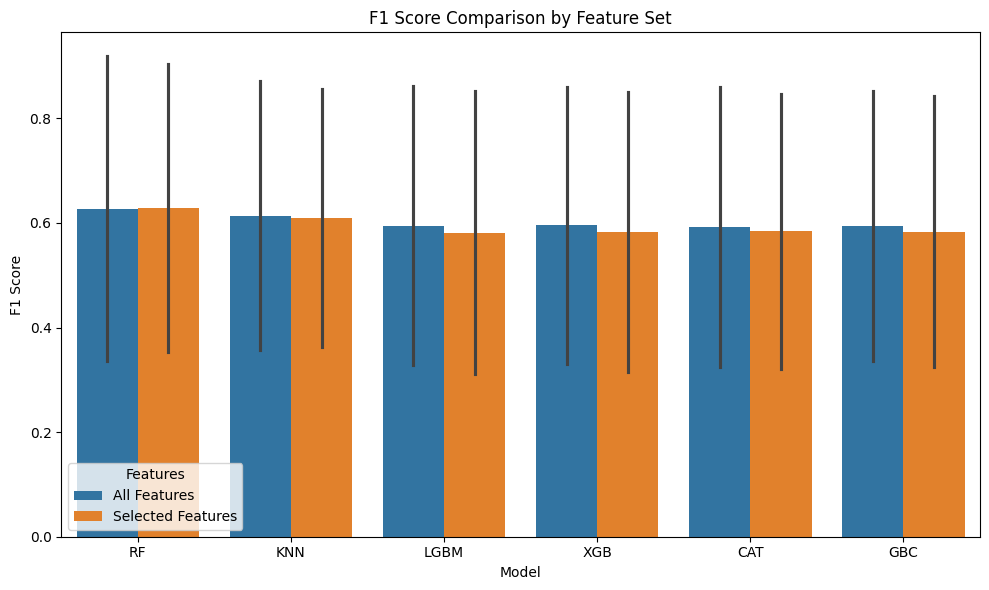

In [ ]:
# --- Output Results ---
results_test_df = pd.DataFrame(results_test)
results_test_df = results_test_df.sort_values(by="F1", ascending=False)

print("\n--- Results for All Features ---")
print(results_test_df[results_test_df["Features"] == "All Features"].sort_values(by="F1", ascending=False))

print("\n--- Results for Selected Features ---")
print(results_test_df[results_test_df["Features"] == "Selected Features"].sort_values(by="F1", ascending=False))

print("\n--- Average Metrics by Model and Feature Set ---")
summary = results_test_df.groupby(["Model", "Features"])[
    ["F1", "Accuracy", "Precision", "Recall"]
].mean().unstack().round(4)
print(summary)

plt.figure(figsize=(10, 6))
sns.barplot(data=results_test_df, x="Model", y="F1", hue="Features", ci="sd")
plt.title("F1 Score Comparison by Feature Set")
plt.ylabel("F1 Score")
plt.tight_layout()
plt.show()



--- Best Configuration per Model ---
   Model        F1  Accuracy      Sampling  Split   Set      Features  \
13    RF  0.869879  0.864337  Oversampling  80/20  Test  All Features   
16   KNN  0.829439  0.811917  Oversampling  80/20  Test  All Features   
21  LGBM  0.771933  0.762803  Oversampling  70/30  Test  All Features   
18   XGB  0.771889  0.762383  Oversampling  70/30  Test  All Features   
23   CAT  0.767271  0.757994  Oversampling  70/30  Test  All Features   
20   GBC  0.762876  0.753322  Oversampling  70/30  Test  All Features   

                                                                           Best Params  
13                              {'model__max_depth': None, 'model__n_estimators': 100}  
16                                                           {'model__n_neighbors': 3}  
21  {'model__learning_rate': 0.1, 'model__n_estimators': 100, 'model__num_leaves': 50}  
18    {'model__learning_rate': 0.1, 'model__max_depth': 6, 'model__n_estimators': 100}  
23   

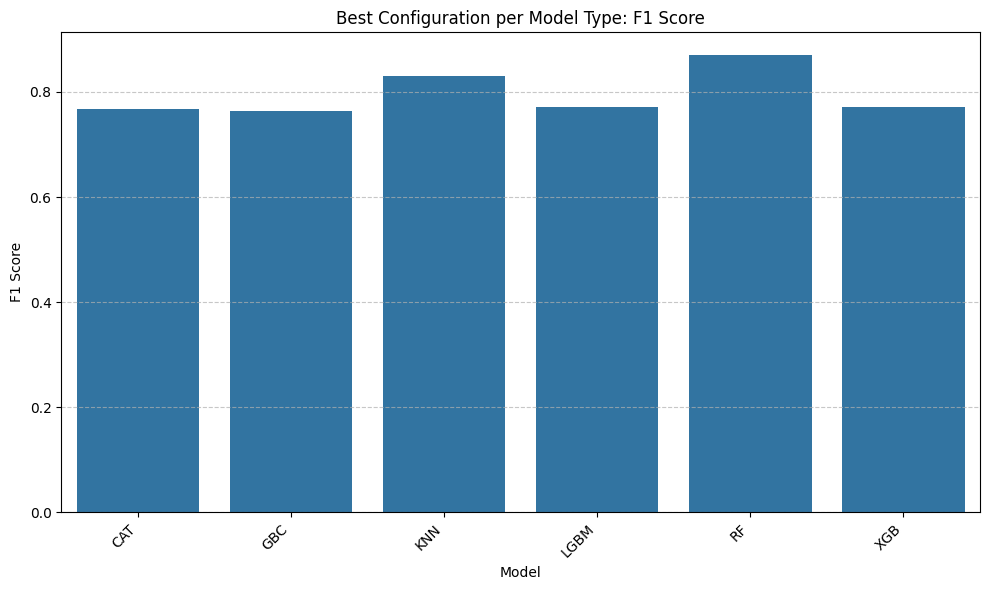

In [ ]:
# Select best performing model per type (highest F1)
pd.set_option('display.max_colwidth', None)
# Select best performing model per type (highest F1)
best_per_model = results_test_df.loc[results_test_df.groupby("Model")["F1"].idxmax()].copy()

columns_to_show = [
    "Model", "F1", "Accuracy", "Sampling", "Split", "Set", "Features", "Best Params"
]

# --- Prevent truncation of long dictionary outputs ---
pd.set_option('display.max_colwidth', None)

print("\n--- Best Configuration per Model ---")
print(best_per_model[columns_to_show].sort_values(by="F1", ascending=False))

# Use bar plot to visualize the best F1 scores
plt.figure(figsize=(10, 6))
sns.barplot(data=best_per_model, x='Model', y='F1')
plt.title('Best Configuration per Model Type: F1 Score')
plt.ylabel('F1 Score')
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



# Results:
1. Best-performing Model: RF with oversampling for balancing, 80/20 test split and all features as independent variables
2. Including all features performs overall better than selected features from initial pre-processing
3. Oversampling consistently performs best among employed models (by f1 metric)
4. Still: Suspicious of overfitting

Next: Check RF